<a href="https://colab.research.google.com/github/roborew/ComputerVision/blob/main/MASK_RCNN_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import torch
import torch.functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn
# from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

import cv2
import numpy as np
import matplotlib.pyplot as plt


https://pytorch.org/vision/main/models/mask_rcnn.html

COCO dataset, if we wanted to retrain

In [122]:
# gdown.download("http://images.cocodataset.org/zips/val2017.zip", "val2017.zip")
# !unzip "val2017.zip" -d /content/data

# gdown.download("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", "annotations_trainval2017.zip")
# !unzip "annotations_trainval2017.zip" -d /content/data

Upload an image for using with the model.

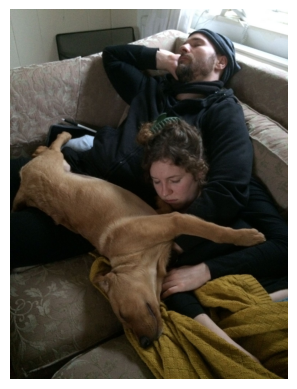

In [8]:
import matplotlib.pyplot as plt
img_path = '/Users/robo/REPOS/AI/ComputerVision/pytorch_mask_rcnn/WhatsApp Image 2024-03-31 at 18.20.10.jpeg'
# Read and display the image
img = plt.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Optional: to not show axes for a cleaner image
plt.show()

Using pretrained maskrcnn

In [22]:
# Load a pre-trained Mask R-CNN model
model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
# model = maskrcnn_resnet50_fpn_v2(pretrained=True)
mps_device = torch.device("mps")
model.to(mps_device)

model.eval()  # Set the model to evaluation mode

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [19]:
mps_device

device(type='mps')

Convert image to tensor

In [43]:
# Load an image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (320, 320))

# Convert the image to a tensor
image_tensor = torch.from_numpy(image / 255.).permute(2, 0, 1).float().unsqueeze(0)
device = torch.device("cpu")
model = model.to(device)
image_tensor = image_tensor.to(device)

In [31]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [39]:
image_tensor

tensor([[[[0.6039, 0.6157, 0.6000,  ..., 0.9961, 0.9961, 0.9961],
          [0.6118, 0.6157, 0.6314,  ..., 0.9961, 0.9922, 0.9922],
          [0.6078, 0.6275, 0.6157,  ..., 0.9765, 0.9686, 0.9725],
          ...,
          [0.0392, 0.0314, 0.0510,  ..., 0.0627, 0.0510, 0.0627],
          [0.0471, 0.0510, 0.0667,  ..., 0.0510, 0.0784, 0.0549],
          [0.0706, 0.0353, 0.0392,  ..., 0.0549, 0.0667, 0.0627]],

         [[0.6471, 0.6471, 0.6235,  ..., 1.0000, 1.0000, 1.0000],
          [0.6510, 0.6471, 0.6549,  ..., 1.0000, 1.0000, 1.0000],
          [0.6314, 0.6471, 0.6392,  ..., 0.9961, 0.9882, 0.9882],
          ...,
          [0.0392, 0.0235, 0.0392,  ..., 0.0392, 0.0275, 0.0392],
          [0.0471, 0.0431, 0.0549,  ..., 0.0235, 0.0510, 0.0235],
          [0.0510, 0.0275, 0.0392,  ..., 0.0314, 0.0392, 0.0314]],

         [[0.5922, 0.5961, 0.5765,  ..., 1.0000, 1.0000, 1.0000],
          [0.6118, 0.6039, 0.6157,  ..., 1.0000, 0.9961, 0.9961],
          [0.6039, 0.6196, 0.6078,  ..., 0

In [44]:
with torch.no_grad():
    predictions = model(image_tensor)

# # Extract masks for detected people
people_masks = [mask for mask, label in zip(predictions[0]['masks'], predictions[0]['labels']) if label == 1]

In [41]:
blurred_image = image.copy()
CONFIDENCE = 0.9 # @param {type:"slider", min:0, max:1, step:0.1}
for mask in people_masks:
    binary_mask = mask[0] > CONFIDENCE  # Convert mask to binary
    for i in range(3):  # Iterate over each color channel
        # Apply blurring on the masked area
        blurred_image[:, :, i] = np.where(binary_mask.cpu().numpy(), cv2.GaussianBlur(blurred_image[:, :, i], (31, 31), 50), blurred_image[:, :, i])

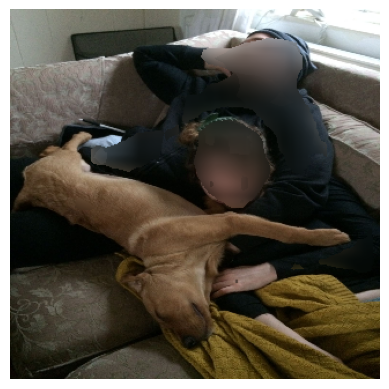

In [45]:
# Convert back to BGR for OpenCV
plt.imshow(blurred_image)
plt.axis('off')  # Optional: to not show axes for a cleaner image
plt.show()

Define class names and colours

In [14]:
# Define a list of colors
colors = [
    "red", "green", "blue", "yellow", "purple", "orange", "lime", "cyan", "magenta", "pink",
    "navy", "maroon", "olive", "teal", "brown", "black", "gray", "violet", "gold", "silver",
]

COCO_INSTANCE_CATEGORY_NAMES = [
    'BG', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

class_colors = {cls: colors[i % len(colors)] for i, cls in enumerate(COCO_INSTANCE_CATEGORY_NAMES)}

Class detection with bounding box

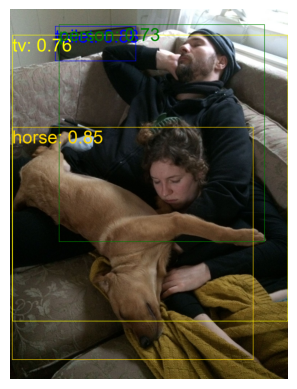

In [16]:
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import torch

# Predict and visualize
with torch.no_grad():
    predictions = model(image_tensor)

# Extract the bounding boxes, labels, and scores
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Convert the image tensor back to a PIL image for easier manipulation
image_np = image_tensor.squeeze().cpu().numpy()
image_np = np.transpose(image_np, (1, 2, 0))  # Change from (C, H, W) to (H, W, C)
image_np = (image_np * 255).astype(np.uint8)  # Scale back to [0-255] from [0-1]
image_pil = Image.fromarray(image_np)

CONFIDENCE_THRESHOLD = 0.7 # @param {type:"slider", min:0, max:1, step:0.1}

font_size = 100
font_path = '/Library/Fonts/Arial.ttf'
font = ImageFont.truetype(font_path, font_size)

# Draw the bounding boxes and labels on the image
draw = ImageDraw.Draw(image_pil)
for box, label, score in zip(boxes, labels, scores):
    if score > CONFIDENCE_THRESHOLD:  # Only consider detections with a confidence score above a threshold (e.g., 50%)
        box = box.cpu().numpy()
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        color = class_colors.get(class_name, 'white')

        # Draw the box
        draw.rectangle([(box[0], box[1]), (box[2], box[3])], outline=color, width=3)

        # Annotate the box with the class name
        draw.text((box[0], box[1]), f"{class_name}: {score:.2f}", fill=color, font=font)

# Display the image with bounding boxes and labels
image_pil.show()
plt.axis('off')  # Optional: to not show axes for a cleaner image
# Convert back to BGR for OpenCV
plt.imshow(image_pil)



Table of preditions

In [17]:
import pandas as pd

data = []
for box, label, score in zip(boxes, labels, scores):
    label_index = label.item()  # Adjust for zero-based indexing
    if label_index >= 0 and label_index < len(COCO_INSTANCE_CATEGORY_NAMES):
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label_index]
    else:
        class_name = 'Unknown'  # Use a placeholder for out-of-range labels
    data.append({
        'Box (xmin, ymin, xmax, ymax)': f'({box[0]:.2f}, {box[1]:.2f}, {box[2]:.2f}, {box[3]:.2f})',
        'Label': class_name,
        'Score': f'{score:.2f}'
    })

df = pd.DataFrame(data)
df

,"Box (xmin, ymin, xmax, ymax)",Label,Score
0,"(249.15, 94.69, 696.74, 288.03)",toilet,0.88
1,"(11.89, 653.51, 1344.56, 1941.74)",horse,0.85
2,"(13.28, 143.96, 1536.00, 1728.66)",tv,0.76
3,"(270.83, 85.81, 1407.33, 1289.00)",person,0.73
4,"(1.44, 140.29, 834.25, 1189.51)",tv,0.65
5,"(216.46, 533.82, 1502.32, 1873.02)",person,0.61
6,"(280.60, 599.26, 470.43, 673.92)",clock,0.56
7,"(0.00, 928.41, 1520.80, 2007.89)",mouse,0.55
8,"(0.14, 222.10, 670.79, 870.38)",tv,0.46
9,"(696.41, 589.73, 1153.53, 1154.67)",person,0.40
